# Archive
## This notebook is outdated and an artifact from a previous model iteration. It will not run and is saved only for its existing outputs as a log of the research process
## Bifurcation sweep: annual vs. biennial attractor regions

Maps whether the seasonally-forced model settles onto a period-1 (annual) or
period-2 (biennial) incidence cycle, as a function of `R0` and `beta_1`, with
`gamma`/`phi`/birth/death rates held fixed. See `src/bifurcation.py` for the
full method and rationale.

Set `reference_year` below to roughly the midpoint of your actual calibration
fit window (e.g. 1955 for a 1950-1960 window) -- it's only used to pull a
fixed birth/death rate and starting population so every grid point is
comparable to every other.

## 2. Plot the heatmap

The hatched band marks `config.R0_LITERATURE_RANGE`, the R0 bound calibration
uses for `beta_0`. If the biennial (red) region doesn't overlap that band at
all, that's the likely explanation for why the bounded fit couldn't reach
biennial cycles.

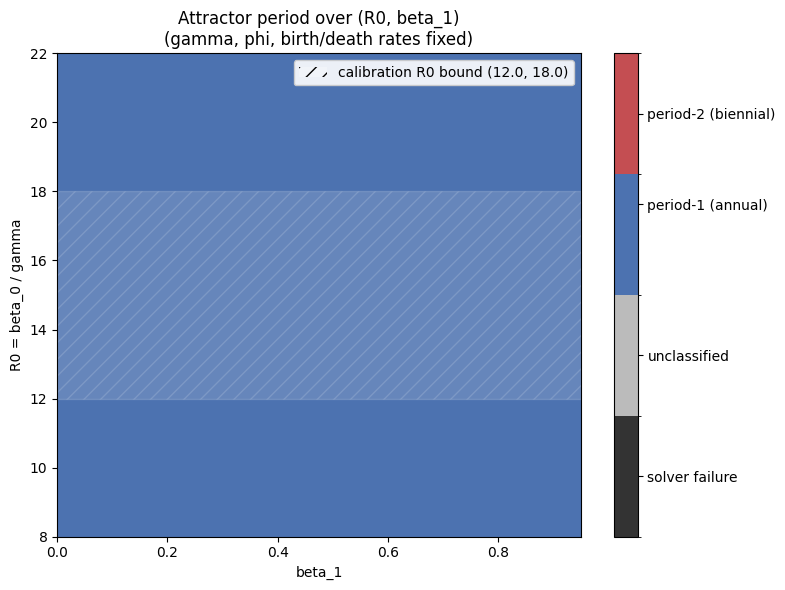

In [ ]:
fig, ax = bifurcation.plot_sweep(sweep_result)

## 3. Quick summary number

Fraction of grid points *within* the literature R0 bound that classify as
biennial. Near 0 means the bound and the biennial regime don't overlap;
substantially above 0 but your calibrated fit still landed on annual means
the optimizer's starting point/search likely needs to target the boundary
specifically, not that the bound itself is the problem.

In [ ]:
frac = bifurcation.fraction_biennial_in_range(sweep_result)
print(f"{frac:.1%} of grid points within R0={config.R0_LITERATURE_RANGE} classify as biennial")

0.0% of grid points within R0=(12.0, 18.0) classify as biennial


---
## 6. Extend to a birth_rate sweep

The (R0, beta_1) sweep alone came back uniformly annual across the grid.
Birth rate (susceptible replenishment) is the other major control on the
annual/biennial bifurcation for seasonally-forced measles-like models
(Earn, Rohani & Grenfell 2000) -- historically, differing birth rates are
part of why some pre-vaccine populations (e.g. England/Wales) showed
biennial cycles while others (e.g. much of the pre-vaccine US) were more
often annual. This section sweeps birth_rate alongside (R0, beta_1) to see
whether/where the boundary is birth-rate-sensitive.

`suggested_birth_rate_grid` brackets your reference year's actual birth
rate (0.5x-2x by default) -- sanity-check the printed reference rate
against known CBR figures for 1950s Texas before trusting the sweep.

In [ ]:
birth_rate_grid = bifurcation.suggested_birth_rate_grid(reference_year, n=4)
print("birth_rate grid (/yr):", np.round(birth_rate_grid, 4))

birth_rate grid (/yr): [0.012  0.0239 0.0359 0.0479]


Run the 3D sweep. This is `len(birth_rate_grid)` times the work of the 2D
sweep -- start with a coarse (R0, beta_1) grid here too before scaling up.

In [ ]:
R0_grid_3d = np.linspace(8.0, 22.0, 6)
beta1_grid_3d = np.linspace(0.0, 0.95, 6)

sweep_3d = bifurcation.run_sweep(
    reference_year=reference_year,
    R0_grid=R0_grid_3d,
    beta1_grid=beta1_grid_3d,
    birth_rate_grid=birth_rate_grid,
)

Reference year 1955: death_rate=0.0095/yr, gamma=45.6562/yr
Sweeping birth_rate over [np.float64(0.012), np.float64(0.0239), np.float64(0.0359), np.float64(0.0479)] (reference_year birth_rate=0.0239/yr, for context)
Grid: 4 birth_rate x 6 R0 x 6 beta_1 = 144 simulations
  birth_rate=0.0120 R0=8.00 done (1/6)
  birth_rate=0.0120 R0=10.80 done (2/6)
  birth_rate=0.0120 R0=13.60 done (3/6)
  birth_rate=0.0120 R0=16.40 done (4/6)
  birth_rate=0.0120 R0=19.20 done (5/6)
  birth_rate=0.0120 R0=22.00 done (6/6)
birth_rate=0.0120 complete (1/4)
  birth_rate=0.0239 R0=8.00 done (1/6)
  birth_rate=0.0239 R0=10.80 done (2/6)
  birth_rate=0.0239 R0=13.60 done (3/6)
  birth_rate=0.0239 R0=16.40 done (4/6)
  birth_rate=0.0239 R0=19.20 done (5/6)
  birth_rate=0.0239 R0=22.00 done (6/6)
birth_rate=0.0239 complete (2/4)
  birth_rate=0.0359 R0=8.00 done (1/6)
  birth_rate=0.0359 R0=10.80 done (2/6)
  birth_rate=0.0359 R0=13.60 done (3/6)
  birth_rate=0.0359 R0=16.40 done (4/6)
  birth_rate=0.0359 R0=19.

One heatmap panel per birth_rate value. Watch for the red (biennial)
region appearing/growing as birth_rate increases -- that's the expected
direction per the theory (higher replenishment rate -> more likely to
support a biennial attractor).

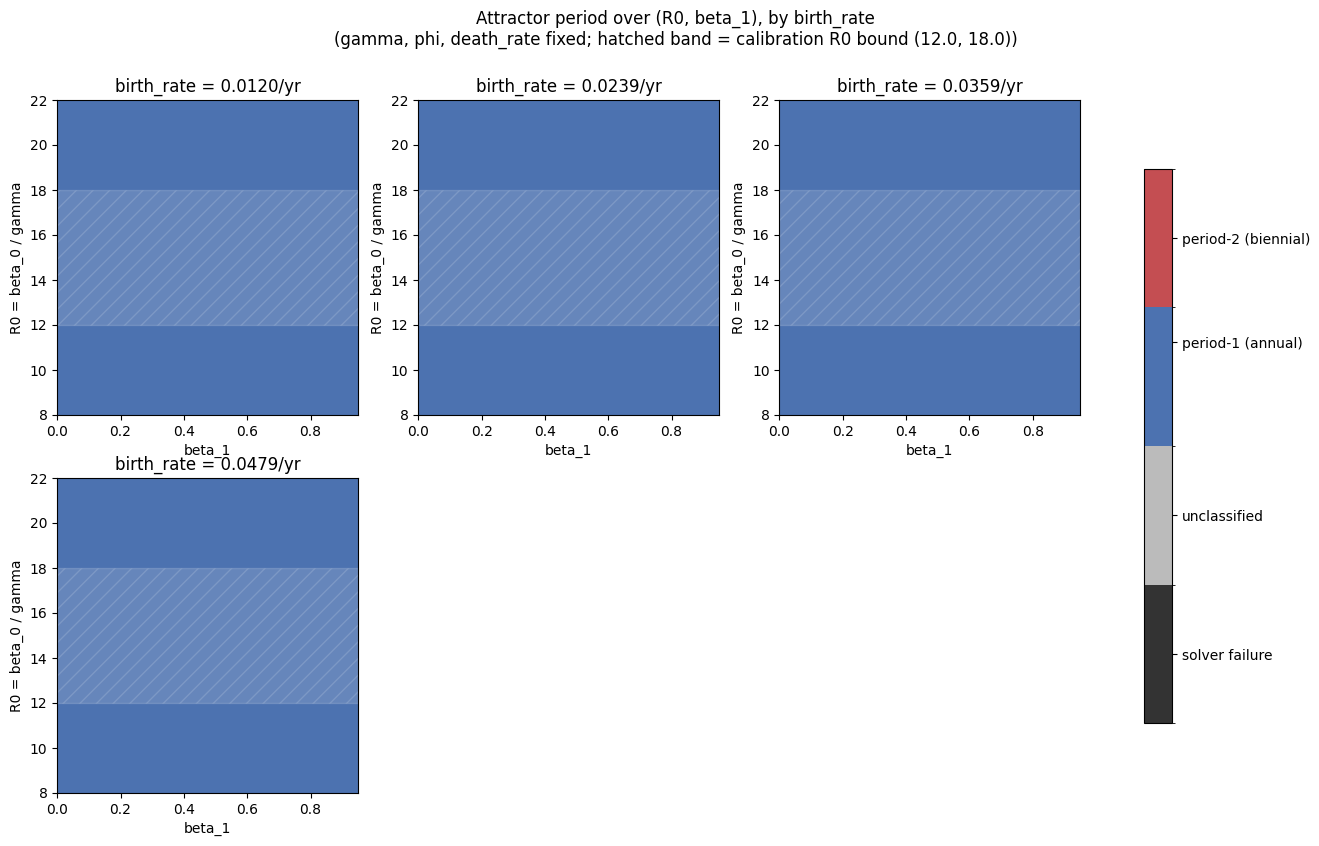

In [ ]:
fig3d, axes3d = bifurcation.plot_sweep(sweep_3d)

Per-birth-rate summary: fraction of grid points *within* the literature
R0 bound that classify as biennial, at each birth rate. If this stays 0
across the whole range you swept, that's a stronger result than the 2D
sweep alone -- it suggests the model doesn't reach the biennial regime for
any birth rate near Texas's actual historical value, not just at one
particular reference year.

In [ ]:
frac_by_birth_rate = bifurcation.fraction_biennial_in_range(sweep_3d)
for br, frac in frac_by_birth_rate.items():
    print(f"birth_rate={br:.4f}/yr: {frac:.1%} of R0-bound grid points biennial")

birth_rate=0.0120/yr: 0.0% of R0-bound grid points biennial
birth_rate=0.0239/yr: 0.0% of R0-bound grid points biennial
birth_rate=0.0359/yr: 0.0% of R0-bound grid points biennial
birth_rate=0.0479/yr: 0.0% of R0-bound grid points biennial


Save the 3D sweep results.

In [ ]:
np.save(out_dir / "periods_3d.npy", sweep_3d["periods"])
np.save(out_dir / "R0_grid_3d.npy", sweep_3d["R0_grid"])
np.save(out_dir / "beta1_grid_3d.npy", sweep_3d["beta1_grid"])
np.save(out_dir / "birth_rate_grid.npy", sweep_3d["birth_rate_grid"])
fig3d.savefig(out_dir / "bifurcation_heatmap_by_birth_rate.png", dpi=150)
print(f"Saved to {out_dir}")

Saved to /Users/camdenwright/Documents/VSCode/Python/Personal Projects/delayed-vaccination/plots/figures/bifurcation_sweep


---
## 7. Diagnostic: inspect a raw trajectory at an extreme grid corner

Zero biennial points anywhere across R0, beta_1, and a 4x birth_rate range
is a strong null -- strong enough that it's worth checking whether the
classifier's 15% peak-ratio threshold is masking *weak* alternation before
concluding the model structurally can't reach the biennial regime.
`inspect_trajectory` runs one point directly and plots the raw incidence
curve with detected peaks and their height ratios printed -- pick the most
"extreme" corner of what you swept (highest R0, highest beta_1, highest
birth_rate) since that's the point most likely to show alternation if any
of the grid does.

R0=22.0, beta_1=0.95, birth_rate=0.0479/yr, phi=0.0 -> 31 peaks detected (per-capita series)
population over window: 86,007,551 -> 271,822,896 (+3.91%/yr)
consecutive peak-height ratios (per-capita): [0.057 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.   ]
classify_period result (per-capita): 1


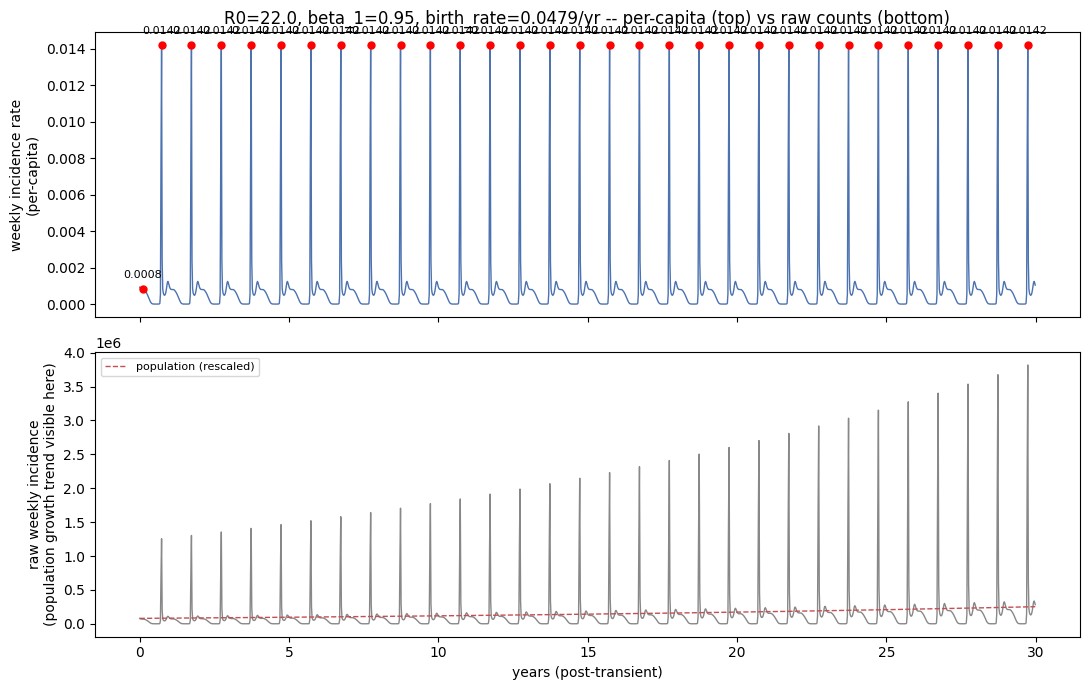

In [ ]:
incidence, peak_idx = bifurcation.inspect_trajectory(
    R0=22.0,
    beta_1=0.95,
    reference_year=reference_year,
    birth_rate=birth_rate_grid.max(),

---
## 8. Fix: classify on per-capita incidence, not raw counts

The section 7 trajectory revealed a confound: peaks were monotonically
*increasing* across the whole 30-year analysis window, never settling.
That's population growth, not epidemic non-convergence -- this is an open
population (births proportional to `N_total(t)`), so whenever
`birth_rate != death_rate`, total population grows or shrinks roughly
exponentially forever and raw incidence counts inherit that trend
regardless of the underlying epidemic period. `run_single` and
`classify_period` in `src/bifurcation.py` are now updated to classify on
the **per-capita incidence rate** (`weekly_incidence / population`)
instead, which is what actually converges to a periodic attractor even
while total population keeps changing.

**Restart the kernel (or re-run the `%load_ext autoreload` cell) before
continuing**, then re-run sections 6 and 7 -- the earlier heatmaps and
diagnostic plot in this notebook were computed on the old (raw-count)
classification and should be treated as stale.

R0=22.0, beta_1=0.95, birth_rate=0.0479/yr, phi=0.0 -> 31 peaks detected (per-capita series)
population over window: 86,007,551 -> 271,822,896 (+3.91%/yr)
consecutive peak-height ratios (per-capita): [0.057 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.   ]
classify_period result (per-capita): 1


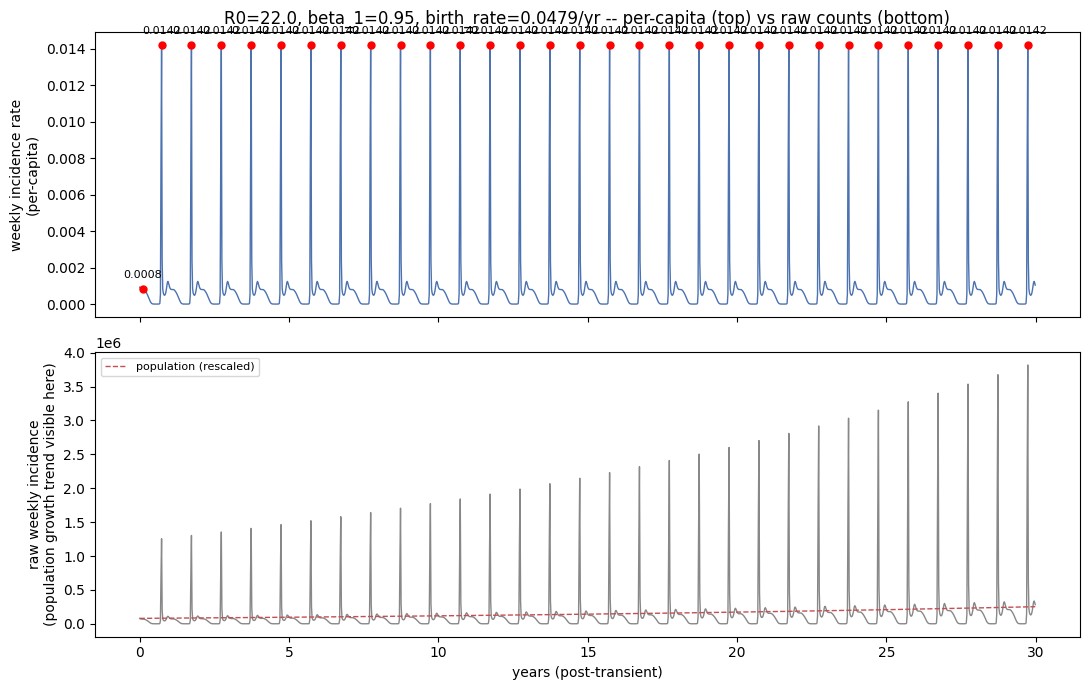

In [ ]:
# Re-run the section 7 diagnostic first, on the same extreme corner, to
# confirm the fix actually changes what we see.
sim, peak_idx = bifurcation.inspect_trajectory(
    R0=22.0,
    beta_1=0.95,
    reference_year=reference_year,
    birth_rate=birth_rate_grid.max(),
)

If the top (per-capita) panel now shows peaks settling into a repeating
pattern rather than growing without bound, the fix worked -- read the
printed ratios the same way as before (flat -> annual, consistent
alternation -> biennial). Once this looks right, re-run the section 6
sweep (`bifurcation.run_sweep(...)`) to regenerate the heatmaps on the
corrected, population-normalized classification.

The diagnostic confirms the fix: per-capita peaks are flat (~0.0140-0.0142
throughout), raw counts climb with population. This corner genuinely is
period-1 -- not a growth artifact. That doesn't yet tell us about the rest
of the grid, though (weaker forcing / different birth rates could behave
differently once population growth isn't masking or manufacturing
alternation). Re-run the full section 6 sweep now that classification is
corrected, before concluding anything about the grid as a whole.

Reference year 1955: death_rate=0.0095/yr, gamma=45.6562/yr
Sweeping birth_rate over [np.float64(0.012), np.float64(0.0239), np.float64(0.0359), np.float64(0.0479)] (reference_year birth_rate=0.0239/yr, for context)
Grid: 4 birth_rate x 6 R0 x 6 beta_1 = 144 simulations
  birth_rate=0.0120 R0=8.00 done (1/6)
  birth_rate=0.0120 R0=10.80 done (2/6)
  birth_rate=0.0120 R0=13.60 done (3/6)
  birth_rate=0.0120 R0=16.40 done (4/6)
  birth_rate=0.0120 R0=19.20 done (5/6)
  birth_rate=0.0120 R0=22.00 done (6/6)
birth_rate=0.0120 complete (1/4)
  birth_rate=0.0239 R0=8.00 done (1/6)
  birth_rate=0.0239 R0=10.80 done (2/6)
  birth_rate=0.0239 R0=13.60 done (3/6)
  birth_rate=0.0239 R0=16.40 done (4/6)
  birth_rate=0.0239 R0=19.20 done (5/6)
  birth_rate=0.0239 R0=22.00 done (6/6)
birth_rate=0.0239 complete (2/4)
  birth_rate=0.0359 R0=8.00 done (1/6)
  birth_rate=0.0359 R0=10.80 done (2/6)
  birth_rate=0.0359 R0=13.60 done (3/6)
  birth_rate=0.0359 R0=16.40 done (4/6)
  birth_rate=0.0359 R0=19.

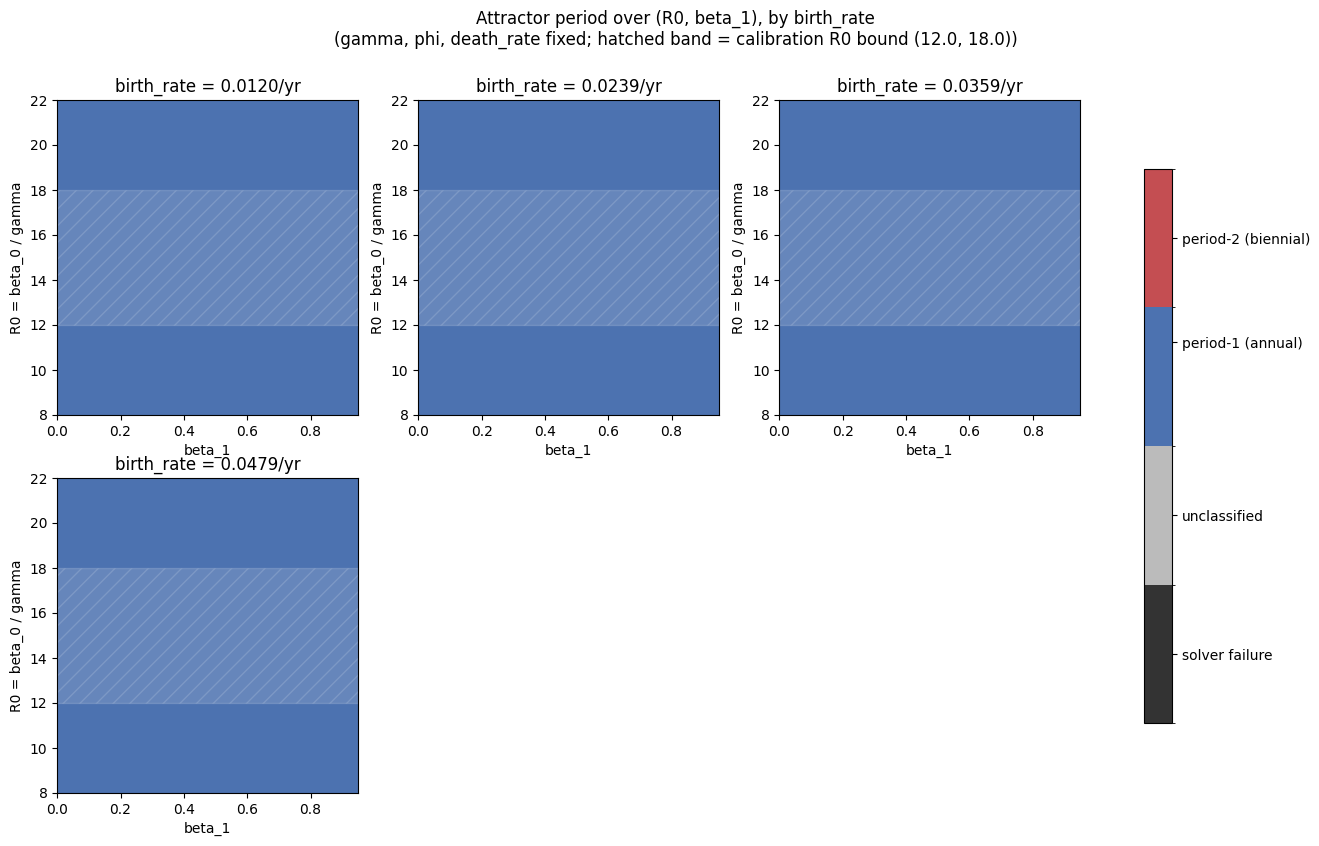

In [ ]:
sweep_3d = bifurcation.run_sweep(
    reference_year=reference_year,
    R0_grid=R0_grid_3d,
    beta1_grid=beta1_grid_3d,
    birth_rate_grid=birth_rate_grid,
)
fig3d, axes3d = bifurcation.plot_sweep(sweep_3d)

In [ ]:
frac_by_birth_rate = bifurcation.fraction_biennial_in_range(sweep_3d)
for br, frac in frac_by_birth_rate.items():
    print(f"birth_rate={br:.4f}/yr: {frac:.1%} of R0-bound grid points biennial")

birth_rate=0.0120/yr: 0.0% of R0-bound grid points biennial
birth_rate=0.0239/yr: 0.0% of R0-bound grid points biennial
birth_rate=0.0359/yr: 0.0% of R0-bound grid points biennial
birth_rate=0.0479/yr: 0.0% of R0-bound grid points biennial
